# Topic 10 Lab: Monte Carlo vs. Temporal Difference on a 10x10 GridWorld

We scale the model-free prediction methods from Topics 8 (MC) and 9 (TD) up to a
**10x10 GridWorld with obstacles** and run a controlled comparison: MC vs TD,
a learning-rate sweep, value heatmaps, and finally **turning the learned value
function into a path** with policy iteration (Topic 6).

## 1. The environment (10x10 grid with obstacles)

Reward is $-1$ per step, the policy is uniform random, start is top-left and the
goal is bottom-right. Moving into a wall leaves the agent in place.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

N, GOAL, GAMMA = 10, (9, 9), 0.9
ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]          # up, down, left, right

OBST = set()
for r in range(0, 7):  OBST.add((r, 3))               # col 3 wall, gap at bottom
for r in range(3, 10): OBST.add((r, 6))               # col 6 wall, gap at top
OBST.add((7, 8)); OBST.add((8, 8))                    # stub near the goal
OBST.discard((0, 0)); OBST.discard(GOAL)

def free(r, c):
    return 0 <= r < N and 0 <= c < N and (r, c) not in OBST

FREE = [(r, c) for r in range(N) for c in range(N) if free(r, c)]
NONTERM = [s for s in FREE if s != GOAL]

def step(s, a):
    r, c = s; dr, dc = ACTIONS[a]; nr, nc = r + dr, c + dc
    if not free(nr, nc): nr, nc = r, c                # wall: stay in place
    ns = (nr, nc)
    return ns, -1, (ns == GOAL)

print("free cells:", len(FREE), "| obstacles:", len(OBST))

free cells: 84 | obstacles: 16


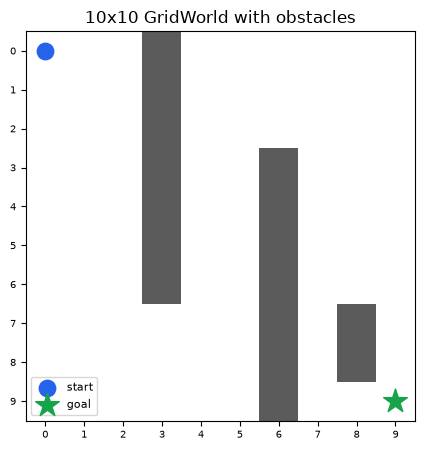

In [2]:
img = np.zeros((N, N))
for (r, c) in OBST: img[r, c] = 1
plt.figure(figsize=(4.6, 4.6))
plt.imshow(img, cmap="Greys", vmin=0, vmax=1.4)
plt.scatter([0], [0], marker="o", s=140, color="#2563eb", label="start", zorder=3)
plt.scatter([GOAL[1]], [GOAL[0]], marker="*", s=320, color="#16a34a", label="goal", zorder=3)
plt.xticks(range(N)); plt.yticks(range(N)); plt.tick_params(labelsize=7)
plt.title("10x10 GridWorld with obstacles"); plt.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

## 2. The true values (dynamic programming reference)

Because we *built* the model, we can compute the exact $V^\pi$ of the random
policy by iterative policy evaluation. It is used **only as a yardstick**; MC and
TD never see it.

In [3]:
def dp_reference():
    V = {s: 0.0 for s in FREE}
    for _ in range(20000):
        delta = 0.0
        for s in NONTERM:
            v = sum(0.25 * (step(s, a)[1] + GAMMA * V[step(s, a)[0]]) for a in range(4))
            delta = max(delta, abs(v - V[s])); V[s] = v
        if delta < 1e-9: break
    return V

V_TRUE = dp_reference()
true_vec = np.array([V_TRUE[s] for s in NONTERM])
def rms(V): return float(np.sqrt(np.mean((np.array([V[s] for s in NONTERM]) - true_vec) ** 2)))
print("true V range: %.2f .. %.2f" % (min(V_TRUE.values()), max(V_TRUE.values())))

true V range: -10.00 .. 0.00


## 3. Monte Carlo and TD, as learners

**MC** averages the whole-episode return; **TD** updates every step toward
$R + \gamma V(s')$. Both use exploring starts and constant step-size $\alpha$.

In [4]:
def run_mc(alpha, episodes, rng, ms=200):
    V = {s: 0.0 for s in FREE}; curve = np.empty(episodes)
    for k in range(episodes):
        s = NONTERM[rng.integers(len(NONTERM))]; traj = []; done = False; t = 0
        while not done and t < ms:
            a = rng.integers(4); ns, r, done = step(s, a); traj.append((s, r)); s = ns; t += 1
        G = 0.0
        for s_t, r_t in reversed(traj):
            G = r_t + GAMMA * G; V[s_t] += alpha * (G - V[s_t])
        curve[k] = rms(V)
    return curve, V

def run_td(alpha, episodes, rng, ms=200):
    V = {s: 0.0 for s in FREE}; curve = np.empty(episodes)
    for k in range(episodes):
        s = NONTERM[rng.integers(len(NONTERM))]; done = False; t = 0
        while not done and t < ms:
            a = rng.integers(4); ns, r, done = step(s, a)
            target = r + (0.0 if done else GAMMA * V[ns]); V[s] += alpha * (target - V[s]); s = ns; t += 1
        curve[k] = rms(V)
    return curve, V

def many_runs(fn, alpha, episodes, seeds):
    curves = np.stack([fn(alpha, episodes, np.random.default_rng(100 + i))[0] for i in range(seeds)])
    return curves.mean(0), curves.std(0)

## 4. Experiment 1, MC vs TD (mean $\pm$ std over 30 runs)

We plot the average RMS-error curve with a shaded $\pm 1$ std band across runs.

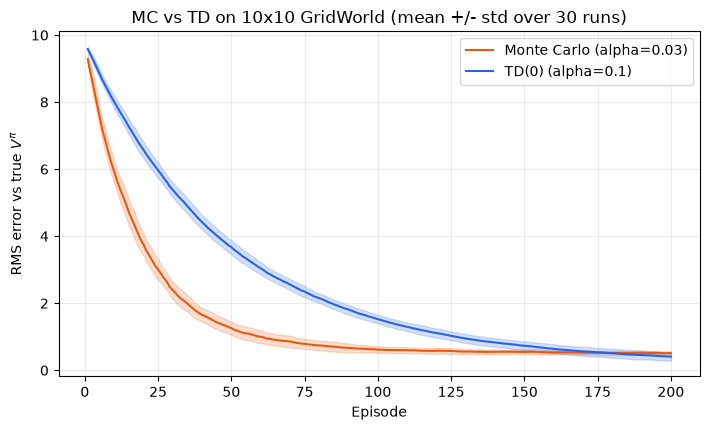

final RMS  MC=0.514  TD=0.406


In [5]:
EP, SEEDS = 200, 30
x = np.arange(1, EP + 1)
mc_m, mc_s = many_runs(run_mc, 0.03, EP, SEEDS)
td_m, td_s = many_runs(run_td, 0.10, EP, SEEDS)

plt.figure(figsize=(7.2, 4.4))
plt.plot(x, mc_m, color="#ea580c", label="Monte Carlo (alpha=0.03)")
plt.fill_between(x, mc_m - mc_s, mc_m + mc_s, color="#ea580c", alpha=0.2)
plt.plot(x, td_m, color="#2563eb", label="TD(0) (alpha=0.1)")
plt.fill_between(x, td_m - td_s, td_m + td_s, color="#2563eb", alpha=0.2)
plt.xlabel("Episode"); plt.ylabel(r"RMS error vs true $V^\pi$")
plt.title("MC vs TD on 10x10 GridWorld (mean +/- std over %d runs)" % SEEDS)
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()
print("final RMS  MC=%.3f  TD=%.3f" % (mc_m[-1], td_m[-1]))

## 5. Experiment 2, the effect of the learning rate $\alpha$

Holding everything else fixed, sweep TD's step size.

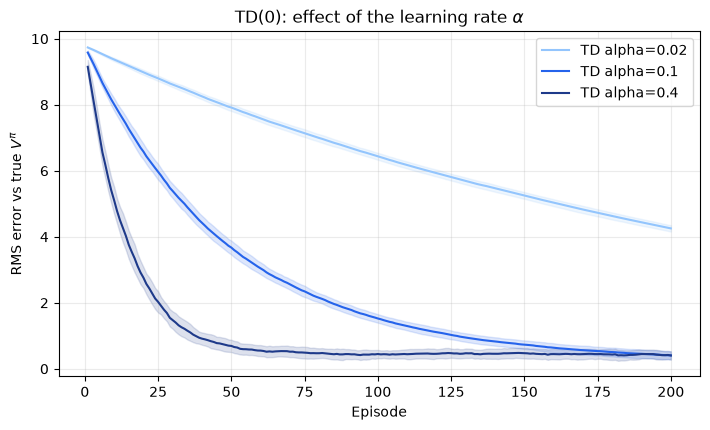

In [6]:
plt.figure(figsize=(7.2, 4.4))
for alpha, col in [(0.02, "#93c5fd"), (0.1, "#2563eb"), (0.4, "#1e3a8a")]:
    m, s = many_runs(run_td, alpha, EP, SEEDS)
    plt.plot(x, m, color=col, label=f"TD alpha={alpha}")
    plt.fill_between(x, m - s, m + s, color=col, alpha=0.15)
plt.xlabel("Episode"); plt.ylabel(r"RMS error vs true $V^\pi$")
plt.title(r"TD(0): effect of the learning rate $\alpha$")
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()

## 6. Do the learned values look right?

Train each method longer and compare the learned tables to the DP truth.

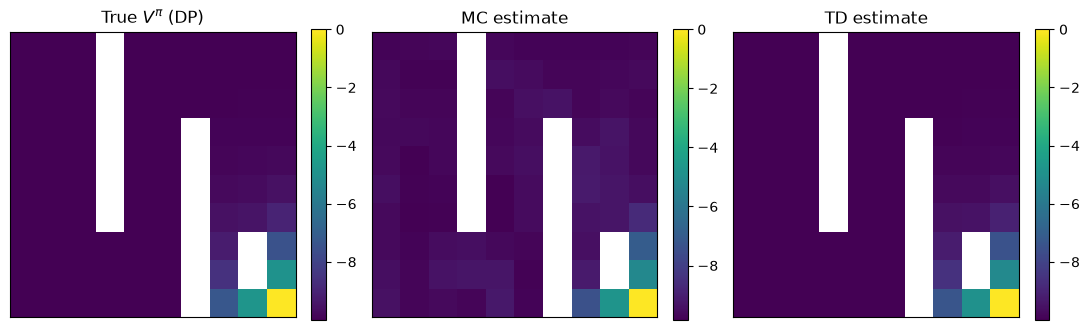

In [7]:
def to_img(Vd):
    a = np.full((N, N), np.nan)
    for s, v in Vd.items(): a[s] = v
    return a

_, Vmc = run_mc(0.02, 12000, np.random.default_rng(1))
_, Vtd = run_td(0.05, 12000, np.random.default_rng(1))
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
for a, (t, Vd) in zip(ax, [(r"True $V^\pi$ (DP)", V_TRUE), ("MC estimate", Vmc), ("TD estimate", Vtd)]):
    im = a.imshow(to_img(Vd), cmap="viridis"); a.set_title(t); a.set_xticks([]); a.set_yticks([])
    fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

## 7. From values to a path: watching it learn

Greedy one-step lookahead $a^\star(s)=\arg\max_a[R+\gamma V(s')]$ turns $V$ into a
path. The random-policy $V$ is nearly **flat** far from the goal, so greedy has
nothing to follow. The fix is the **policy-iteration** loop from Topic 6, using
only state values: **evaluate** the policy with MC (or TD), **act greedily** on
the resulting $V$, and **repeat**. Each round the greedy path gets better.

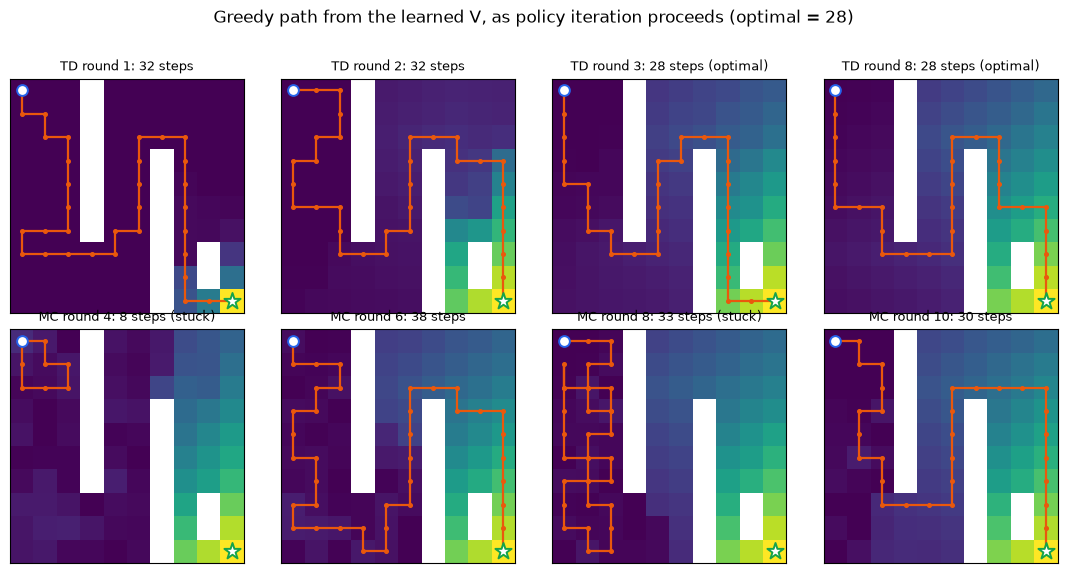

In [8]:
SHORT = None
def bfs_shortest():
    dist = {GOAL: 0}; q = deque([GOAL])
    while q:
        s = q.popleft()
        for dr, dc in ACTIONS:
            nb = (s[0] - dr, s[1] - dc)
            if free(*nb) and nb not in dist:
                dist[nb] = dist[s] + 1; q.append(nb)
    return dist[(0, 0)]
SHORT = bfs_shortest()

def greedy_policy(V):
    return {s: int(np.argmax([step(s, a)[1] + GAMMA * V[step(s, a)[0]] for a in range(4)]))
            for s in NONTERM}

def path_from_V(V, ms=100):
    s = (0, 0); path = [s]; seen = {s}
    for _ in range(ms):
        if s == GOAL: break
        qs = [step(s, a)[1] + GAMMA * V[step(s, a)[0]] for a in range(4)]
        order = np.argsort(-np.array(qs), kind="stable"); nxt = None
        for a in order:
            ns = step(s, int(a))[0]
            if ns != s and ns not in seen: nxt = ns; break
        if nxt is None: nxt = step(s, int(order[0]))[0]
        if nxt == s: break
        s = nxt; seen.add(s); path.append(s)
    return path, (s == GOAL)

def mc_eval(pi, V, rng, ep, alpha, eps, ms=200):
    V = dict(V)
    for _ in range(ep):
        s = NONTERM[rng.integers(len(NONTERM))]; traj = []; done = False; t = 0
        while not done and t < ms:
            a = rng.integers(4) if rng.random() < eps else pi[s]
            ns, r, done = step(s, a); traj.append((s, r)); s = ns; t += 1
        G = 0.0
        for s_t, r_t in reversed(traj):
            G = r_t + GAMMA * G; V[s_t] += alpha * (G - V[s_t])
    return V

def td_eval(pi, V, rng, ep, alpha, eps, ms=200):
    V = dict(V)
    for _ in range(ep):
        s = NONTERM[rng.integers(len(NONTERM))]; done = False; t = 0
        while not done and t < ms:
            a = rng.integers(4) if rng.random() < eps else pi[s]
            ns, r, done = step(s, a); tgt = r + (0.0 if done else GAMMA * V[ns])
            V[s] += alpha * (tgt - V[s]); s = ns; t += 1
    return V

def evolve(evaluator, rng, rounds, ep, alpha):
    V = {s: 0.0 for s in FREE}; pi = {s: int(rng.integers(4)) for s in NONTERM}
    snaps = []
    for k in range(rounds):
        eps = max(0.05, 0.3 * (1 - k / rounds))
        V = evaluator(pi, V, rng, ep, alpha, eps)
        pi = greedy_policy(V)
        p, ok = path_from_V(V); snaps.append((k + 1, p, ok, dict(V)))
    return snaps

td = evolve(td_eval, np.random.default_rng(0), 8, 3000, 0.2)
mc = evolve(mc_eval, np.random.default_rng(2), 10, 12000, 0.05)

def panel(ax, V, p, ok, title):
    ax.imshow(to_img(V), cmap="viridis")
    ax.plot([s[1] for s in p], [s[0] for s in p], "-o", color="#ea580c", ms=2.6, lw=1.6, zorder=2)
    ax.scatter([0], [0], marker="o", s=60, color="w", edgecolors="#2563eb", linewidths=1.4, zorder=3)
    ax.scatter([GOAL[1]], [GOAL[0]], marker="*", s=150, color="w", edgecolors="#16a34a", linewidths=1.4, zorder=3)
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(2, 4, figsize=(11, 5.8))
for j, r in enumerate([1, 2, 3, 8]):
    k, p, ok, V = td[r - 1]
    panel(axes[0, j], V, p, ok, f"TD round {k}: {len(p)-1} steps" + (" (optimal)" if len(p)-1 == SHORT and ok else ""))
for j, r in enumerate([4, 6, 8, 10]):
    k, p, ok, V = mc[r - 1]
    panel(axes[1, j], V, p, ok, f"MC round {k}: {len(p)-1} steps" + ("" if ok else " (stuck)"))
fig.suptitle("Greedy path from the learned V, as policy iteration proceeds (optimal = %d)" % SHORT, fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

Reading across, **TD** finds the goal at once and snaps to the optimal 28-step
route within a couple of rounds. **MC** is noisier: some rounds it finds a good
detour, others its noisy values trap the greedy path (the tangled panels). Same
**bias-variance** story as Experiment 1, now seen as a path being learned.

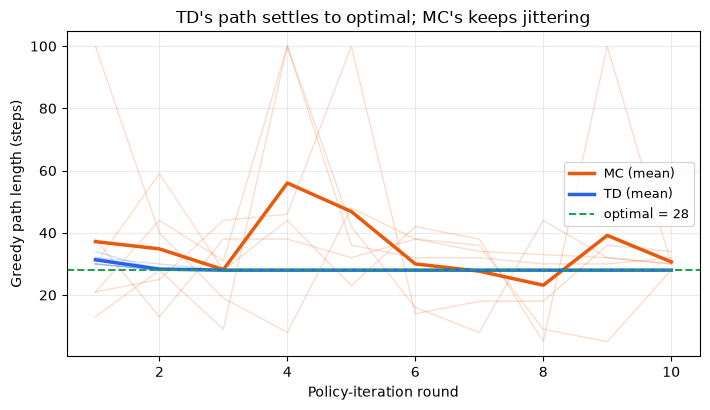

In [9]:
def lengths(evaluator, seeds, rounds, ep, alpha):
    out = []
    for sd in range(seeds):
        out.append([len(p) - 1 for _, p, ok, _ in evolve(evaluator, np.random.default_rng(sd), rounds, ep, alpha)])
    return np.array(out)

R = 10
tdL = lengths(td_eval, 6, R, 3000, 0.2)
mcL = lengths(mc_eval, 6, R, 12000, 0.05)
xx = np.arange(1, R + 1)
plt.figure(figsize=(7.2, 4.2))
for row in mcL: plt.plot(xx, row, color="#ea580c", alpha=0.2, lw=1)
for row in tdL: plt.plot(xx, row, color="#2563eb", alpha=0.2, lw=1)
plt.plot(xx, mcL.mean(0), color="#ea580c", lw=2.5, label="MC (mean)")
plt.plot(xx, tdL.mean(0), color="#2563eb", lw=2.5, label="TD (mean)")
plt.axhline(SHORT, color="#16a34a", ls="--", lw=1.4, label="optimal = %d" % SHORT)
plt.xlabel("Policy-iteration round"); plt.ylabel("Greedy path length (steps)")
plt.title("TD's path settles to optimal; MC's keeps jittering")
plt.legend(fontsize=9); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()

## Assignment 10

**Build your own GridWorld and repeat this study.** Design a *different* grid
(size, obstacles, goal), apply **both MC and TD**, run **many times** and plot the
mean RMS-error curve with a **$\pm$ std shadow** band, do a **parameter study**
over $\alpha$ (table of final errors), and show **value heatmaps** (true vs MC vs
TD). Optionally, reproduce the **path-learning** figures. Submit a **PDF report**
in the same format as our notes and slides.

*(Assignments are numbered by their topic, this is Assignment 10.)*